In [2]:
import networkx as nx
from networkx.algorithms.graph_hashing import weisfeiler_lehman_graph_hash
import matplotlib.pyplot as plt

G1 = nx.cycle_graph(6)
G2 = nx.path_graph(6)

h1 = weisfeiler_lehman_graph_hash(G1)
h2 = weisfeiler_lehman_graph_hash(G2)

print(h1 == h2)  # False if distinguishable by 1-WL


False


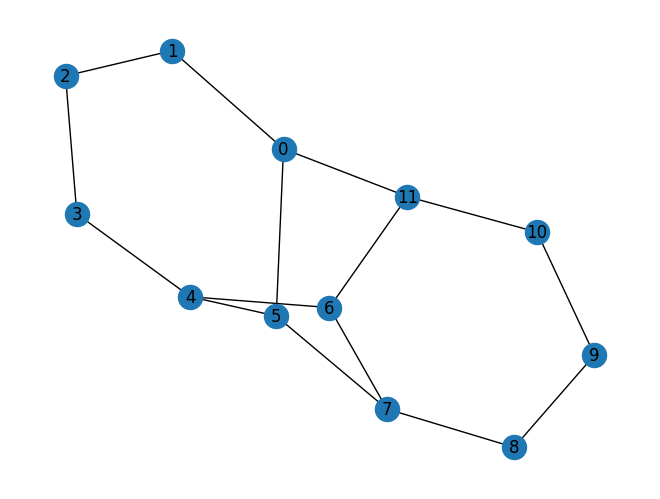

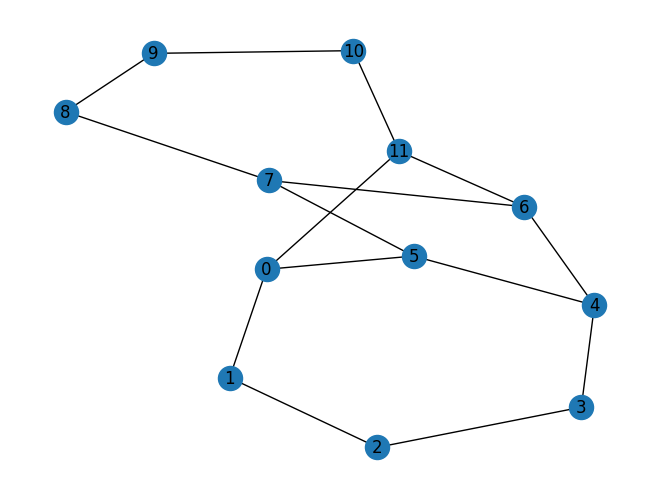

True


In [ ]:


edges1 = [
    (0, 1), (1, 2), (2, 3), (3, 4), (4, 5), (5, 0), # upper hexagon
    (11, 6), (6, 7), (7, 8), (8, 9), (9, 10), (10, 11), # lower hexagon
    (0, 11), (5, 7), (6, 4),
    (6, 9), # breaking isomorphism
]



edges2 = [
    (0, 1), (1, 2), (2, 3), (3, 4), (4, 5), (5, 0), # upper hexagon
    (11, 6), (6, 7), (7, 8), (8, 9), (9, 10), (10, 11), # lower hexagon
    (0, 11), (5, 7), (6, 4),
    (5, 9), # breaking isomorphism
]


G1 = nx.Graph()
G1.add_edges_from(edges1)

G2 = nx.Graph()
G2.add_edges_from(edges2)

nx.draw(G1, with_labels=True)
plt.show()

nx.draw(G2, with_labels=True)
plt.show()

# test wl
h1 = weisfeiler_lehman_graph_hash(G1)
h2 = weisfeiler_lehman_graph_hash(G2)

print(h1 == h2)  # False if distinguishable by 1-WL


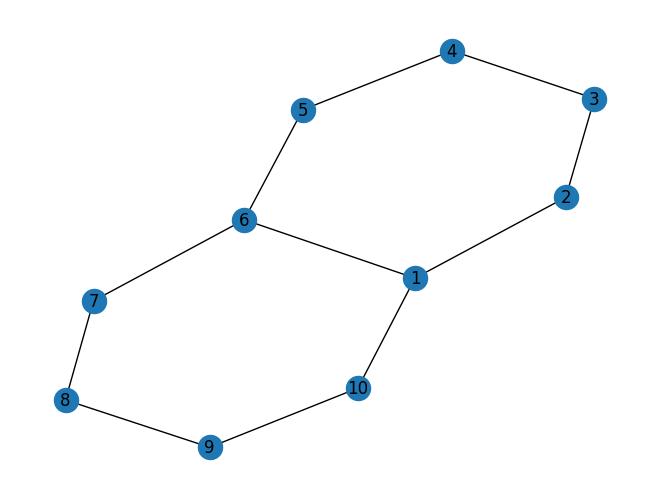

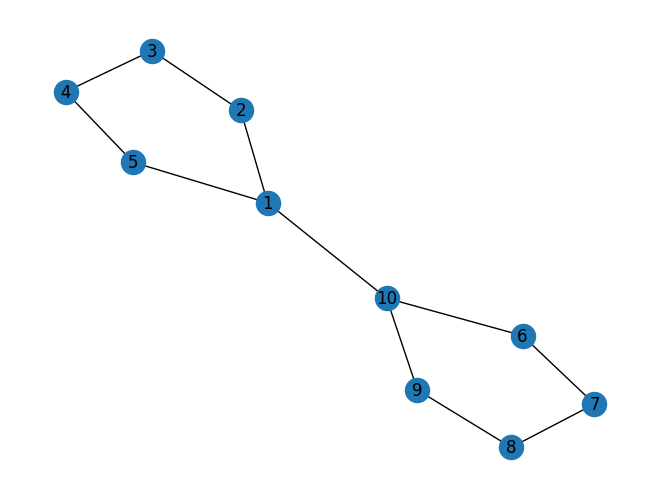

True


In [8]:

# famous 2 hexagons vs 2 pentagons example
edges1 = [
    (1, 2), (2, 3), (3, 4), (4, 5), (5, 6), (6, 7), (7, 8), (8, 9), (9, 10), (10, 1), (1, 6)
]



edges2 = [
    (10, 6), (1, 2), (2, 3), (3, 4), (4, 5), (5, 1), (6, 7), (7, 8), (8, 9), (9, 10), (10, 1)
]


G1 = nx.Graph()
G1.add_edges_from(edges1)

G2 = nx.Graph()
G2.add_edges_from(edges2)

nx.draw(G1, with_labels=True)
plt.show()

nx.draw(G2, with_labels=True)
plt.show()

# test wl
h1 = weisfeiler_lehman_graph_hash(G1)
h2 = weisfeiler_lehman_graph_hash(G2)

print(h1 == h2)  # False if distinguishable by 1-WL


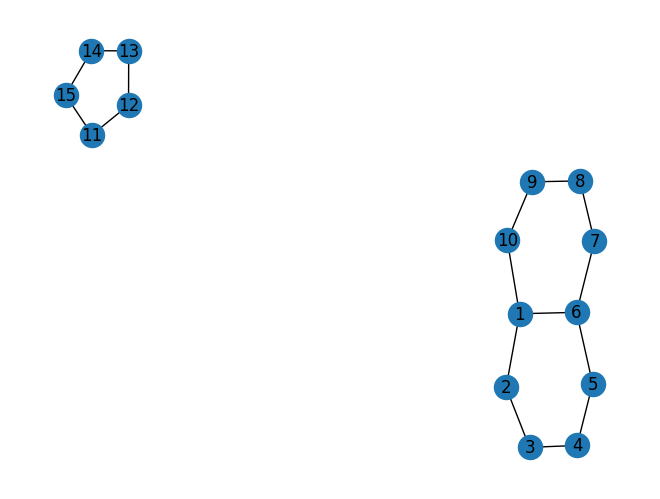

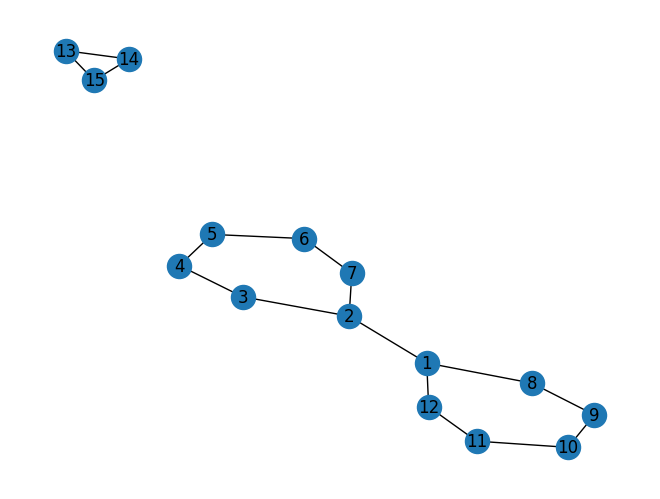

False


In [13]:

# famous 2 hexagons vs 2 pentagons example
edges1 = [
    (1, 2), (2, 3), (3, 4), (4, 5), (5, 6), (6, 7), (7, 8), (8, 9), (9, 10), (10, 1), (1, 6),
    # unconnected pentagon
    (11, 12), (12, 13), (13, 14), (14, 15), (15, 11)
]



edges2 = [
    (2, 3), (3, 4), (4, 5), (5, 6), (6, 7), (7, 2),
    (1, 8), (8, 9), (9, 10), (10, 11), (11, 12), (12, 1),

    (1, 2), 
    # unconnected triangle
    (13, 14), (14, 15), (15, 13)
]


G1 = nx.Graph()
G1.add_edges_from(edges1)

G2 = nx.Graph()
G2.add_edges_from(edges2)

nx.draw(G1, with_labels=True)
plt.show()

nx.draw(G2, with_labels=True)  
plt.show()

# test wl
h1 = weisfeiler_lehman_graph_hash(G1)
h2 = weisfeiler_lehman_graph_hash(G2)

print(h1 == h2)  # False if distinguishable by 1-WL


In [14]:
from grakel import Graph
from grakel.kernels import WeisfeilerLehman
import numpy as np

# Define a simple graph as an edge list with node labels
edges = [(0, 1), (1, 2), (1, 3)]
node_labels = {0: 'A', 1: 'B', 2: 'C', 3: 'D'}

# Create GraKeL graph
g = Graph(edges, node_labels=node_labels)

# WL kernel with access to internal labels
wl = WeisfeilerLehman(n_iter=3)
wl.fit([g])

# Access the final node labels after 3 WL iterations
final_labels = wl.X[0].X, wl.X[1].X, wl.X[2].X
print("Final WL node labels:", final_labels)


Final WL node labels: (array([[1., 1., 1., 1.]]), array([[1., 1., 1., 1.]]), array([[1., 1., 1., 1.]]))


In [9]:
wl.X[0].X, wl.X[1].X, wl.X[2].X

(array([[1., 1., 1.]]), array([[1., 1., 1.]]), array([[1., 1., 1.]]))

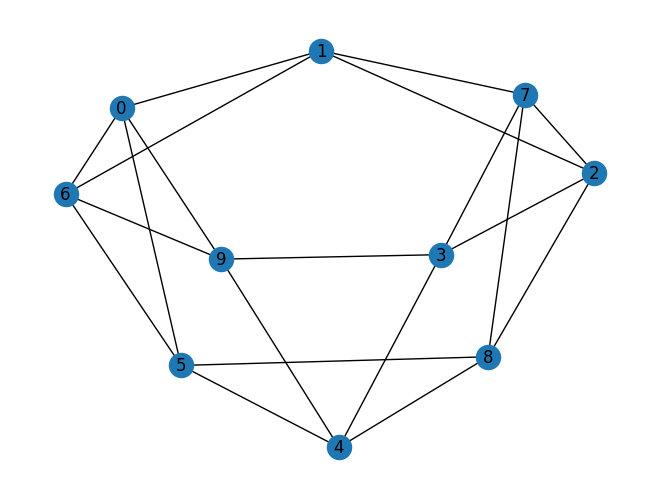

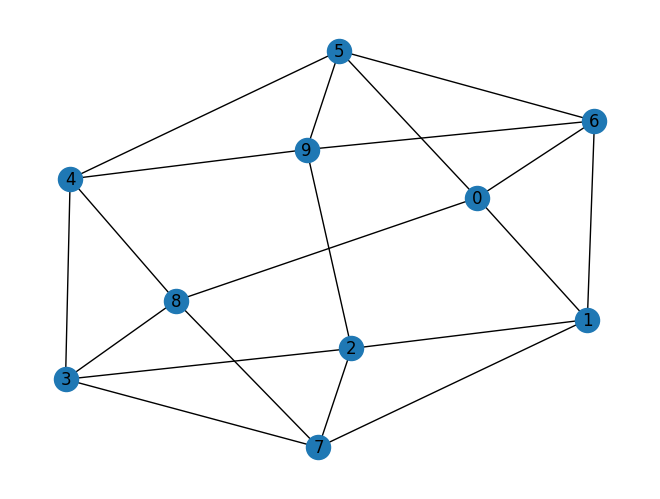

True


In [17]:

# cospectral and 4 regular graphs
edges1 = [
    (0, 1), (0, 6), (0, 9), (0, 5),
    (1,2), (1, 6), (1, 7),
    (2, 3), (2, 7), (2, 8),
    (3, 4), (3, 7), (3, 9),
    (4, 5), (4, 8), (4, 9),
    (5, 6), (5, 8), 
    (6, 9),
    (7, 8)
]

edges2 = [
    # 0 1568
    (0, 1), (0, 5), (0, 6), (0, 8),
    # 1 267
    (1, 2), (1, 6), (1, 7),
    # 2 379
    (2, 3), (2, 7), (2, 9),
    # 3 478
    (3, 4), (3, 7), (3, 8),
    # 4 598
    (4, 5), (4, 9), (4, 8),
    # 5 96
    (5, 6), (5, 9),
    # 6 9
    (6, 9),
    # 7 8
    (7, 8)
]


G1 = nx.Graph()
G1.add_edges_from(edges1)

G2 = nx.Graph()
G2.add_edges_from(edges2)

nx.draw(G1, with_labels=True)
plt.show()

nx.draw(G2, with_labels=True)  
plt.show()

# test wl
h1 = weisfeiler_lehman_graph_hash(G1)
h2 = weisfeiler_lehman_graph_hash(G2)

print(h1 == h2)  # False if distinguishable by 1-WL


In [5]:
# find traingles in G1
nx.triangles(G1), nx.triangles(G2)

({0: 3, 1: 2, 6: 3, 9: 2, 5: 2, 2: 3, 7: 3, 3: 2, 8: 2, 4: 2},
 {0: 2, 1: 2, 5: 3, 6: 3, 8: 2, 2: 2, 7: 3, 3: 3, 9: 2, 4: 2})

In [7]:
triangle_counts = nx.triangles(G1)
for node, count in triangle_counts.items():
    G1.nodes[node]["label"] = str(count)

triangle_counts = nx.triangles(G2)
for node, count in triangle_counts.items():
    G2.nodes[node]["label"] = str(count)

h1 = weisfeiler_lehman_graph_hash(G1, node_attr="label")
h2 = weisfeiler_lehman_graph_hash(G2, node_attr="label")

print(h1 == h2) 

False


In [8]:
cycle_basis = nx.cycle_basis(G1)
for node, count in cycle_basis.items():
    G1.nodes[node]["label"] = str(count)

cycle_basis = nx.cycle_basis(G2)
for node, count in cycle_basis.items():
    G2.nodes[node]["label"] = str(count)

h1 = weisfeiler_lehman_graph_hash(G1, node_attr="label")
h2 = weisfeiler_lehman_graph_hash(G2, node_attr="label")

print(h1 == h2) 

AttributeError: 'list' object has no attribute 'items'

In [16]:

cycle_basis = nx.cycle_basis(G1)
for node in G1.nodes():
    G1.nodes[node]["label"] = 0
for basis in cycle_basis:
    for node in basis:
        G1.nodes[node]["label"] += 1


cycle_basis = nx.cycle_basis(G2)
for node in G2.nodes():
    G2.nodes[node]["label"] = 0
for basis in cycle_basis:
    for node in basis:
        G2.nodes[node]["label"] += 1

h1 = weisfeiler_lehman_graph_hash(G1, node_attr="label")
h2 = weisfeiler_lehman_graph_hash(G2, node_attr="label")

print(h1 == h2) 

False


In [15]:
[G1.nodes[i]["label"] for i in G1.nodes()]

[3, 6, 7, 8, 3, 3, 3, 3, 3, 6]

In [13]:
nx.cycle_basis(G1)

[[3, 9, 4],
 [0, 6, 9],
 [5, 6, 9, 4],
 [0, 1, 6],
 [2, 7, 1],
 [3, 7, 1, 6, 9],
 [8, 7, 1, 6, 9, 4],
 [3, 2, 1, 6, 9],
 [8, 2, 1, 6, 9, 4],
 [5, 0, 9, 4],
 [5, 8, 4]]

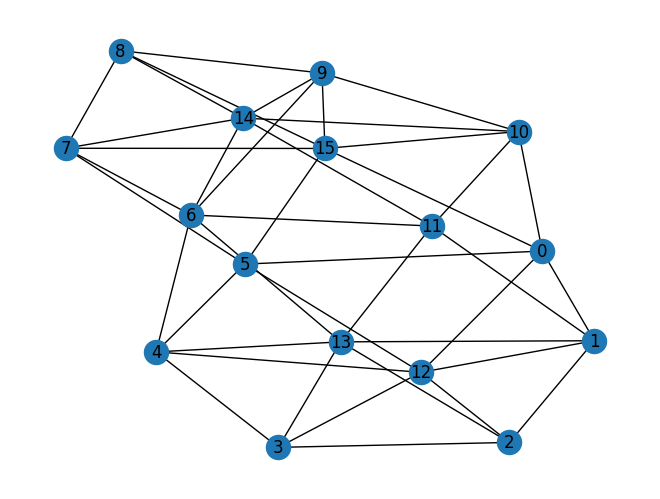

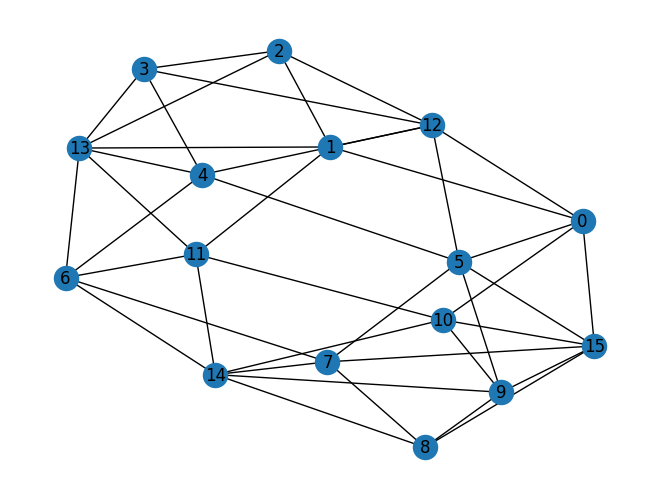

True


In [22]:


edges1 = [
    (0, 1), (1, 2), (2, 3), (3, 4), (4, 5), (5, 0), # upper hexagon
    (11, 6), (6, 7), (7, 8), (8, 9), (9, 10), (10, 11), # lower hexagon
    (1, 11), (0, 10), (4, 6), (5, 7),
    (6, 9), # breaking isomorphism
    (12, 0), (12, 1), (12, 2), (12, 3), (12, 4), (12, 5), # adding vn 1
    (13,11), (13, 1), (13, 2), (13, 3), (13, 4), (13, 6), # adding vn 2
    (14, 6), (14, 7), (14, 8), (14, 9), (14, 10), (14, 11), # adding vn 3
    (15, 5), (15, 7), (15, 8), (15, 9), (15, 10), (15, 0), # adding vn 4
]


edges2 = [
    (0, 1), (1, 2), (2, 3), (3, 4), (4, 5), (5, 0), # upper hexagon
    (11, 6), (6, 7), (7, 8), (8, 9), (9, 10), (10, 11), # lower hexagon
    (1, 11), (0, 10), (4, 6), (5, 7),
    (5, 9), # breaking isomorphism
    (12, 0), (12, 1), (12, 2), (12, 3), (12, 4), (12, 5), # adding vn 1
    (13,11), (13, 1), (13, 2), (13, 3), (13, 4), (13, 6), # adding vn 2
    (14, 6), (14, 7), (14, 8), (14, 9), (14, 10), (14, 11), # adding vn 3
    (15, 5), (15, 7), (15, 8), (15, 9), (15, 10), (15, 0), # adding vn 4    
]


G1 = nx.Graph()
G1.add_edges_from(edges1)

G2 = nx.Graph()
G2.add_edges_from(edges2)

nx.draw(G1, with_labels=True)
plt.show()

nx.draw(G2, with_labels=True)
plt.show()

# test wl
h1 = weisfeiler_lehman_graph_hash(G1)
h2 = weisfeiler_lehman_graph_hash(G2)

print(h1 == h2)  # False if distinguishable by 1-WL
